# Lecture 6: Time Series and Geospatial Analysis

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and python code that implements them -- just like you would see in a textbook. Of course, in a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
But this notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try out changing the code that you see**. In fact, in many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**. 
<br />

### Change everything
But don't feel limited to only change code when I prompt you. This notebook is your learning environment and your playground. I encourage you to try changing and running all the code throughout the notebook and even to **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with or trying to do is really helpful to understand what you were thinking when you revisit it later. 
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, I will ask the same set of questions to try to elicit your questions, reaction and feedback. When we review the reading notebook in class, I encourage you to share these.
</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Validate data merges and joins for correctness
- Master advanced time-based aggregations in pandas
- Implement complex temporal patterns and rolling calculations
- Visualize geospatial data using GeoPandas
- Work with real-world temporal and geographic datasets

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🗺️
  </span>

  This lecture brings together two powerful dimensions of data analysis: **time** and **space**. Whether you're tracking sales trends over months, monitoring incidents over weeks, or mapping customer locations, these skills are essential for real-world business analytics. **Master these techniques and you'll unlock new ways to understand your data!**
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

# 6.0 Code Preface

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import folium
import mapclassify
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set pandas display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

# 6.1 Validating Merges and Joins

<img alt="Validating can eliminate merge bugs" src="../images/L06_brundlefly.png" width="900" style="display:block;">
<font size=2>Jeff Goldblum learned the hard way the consequences of <b>merge bugs</b> when he became Brundlefly in <i>The Fly (1986)</i></font>

One of the most common sources of bugs in data analysis is **incorrect merges**. Pandas won't always warn you when something goes wrong - it will happily return a result that looks reasonable but contains duplicated or missing data.

The consequences can be severe:
- Revenue calculations that double-count some transactions
- Customer analyses that drop important records
- Machine learning models trained on corrupted data

Let's learn how to validate merges properly.

## Setting Up Example Data

Let's create some sample datasets to demonstrate merge validation:

In [2]:
# Create a customers table
customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
})

# Create an orders table
orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106, 107],
    'customer_id': [1, 2, 1, 3, 2, 6, 1],  # Note: customer_id 6 doesn't exist in customers!
    'amount': [150.00, 200.00, 75.00, 300.00, 125.00, 50.00, 225.00]
})

print(f"customers\n{'='*40}\n{customers}\n")
print(f"orders\n{'='*40}\n{orders}\n")

customers
   customer_id     name         city
0            1    Alice     New York
1            2      Bob  Los Angeles
2            3  Charlie      Chicago
3            4    Diana      Houston
4            5      Eve      Phoenix

orders
   order_id  customer_id  amount
0       101            1   150.0
1       102            2   200.0
2       103            1    75.0
3       104            3   300.0
4       105            2   125.0
5       106            6    50.0
6       107            1   225.0



## The Danger: Silent Merge Problems

Watch what happens when we do a basic merge without any validation:

In [3]:
# Simple merge - looks fine, right?
merged = pd.merge(customers, orders, on='customer_id')
print(f"Merged result has {len(merged)} rows\n")
print(f"merged\n{'='*60}\n{merged}\n")

Merged result has 6 rows

merged
   customer_id     name         city  order_id  amount
0            1    Alice     New York       101   150.0
1            1    Alice     New York       103    75.0
2            1    Alice     New York       107   225.0
3            2      Bob  Los Angeles       102   200.0
4            2      Bob  Los Angeles       105   125.0
5            3  Charlie      Chicago       104   300.0



At first glance, this looks fine. But notice:
- We only have 6 rows, but we had 7 orders
- Customer 6's order was **silently dropped** because there's no matching customer!
- Alice (customer 1) appears 3 times because she has 3 orders

This might be exactly what you want... or it might be a serious bug. The problem is that pandas doesn't tell you anything went wrong.

## Using the `indicator` Parameter

The first defense is the `indicator` parameter, which adds a column showing where each row came from:

In [4]:
# Merge with indicator - using outer join to see all data
merged_with_indicator = pd.merge(
    customers, 
    orders, 
    on='customer_id', 
    how='outer',  # Keep all rows from both tables
    indicator=True  # Add a column showing the source
)
print(f"merged_with_indicator\n{'='*70}\n{merged_with_indicator}\n")

merged_with_indicator
   customer_id     name         city  order_id  amount      _merge
0            1    Alice     New York     101.0   150.0        both
1            1    Alice     New York     103.0    75.0        both
2            1    Alice     New York     107.0   225.0        both
3            2      Bob  Los Angeles     102.0   200.0        both
4            2      Bob  Los Angeles     105.0   125.0        both
5            3  Charlie      Chicago     104.0   300.0        both
6            4    Diana      Houston       NaN     NaN   left_only
7            5      Eve      Phoenix       NaN     NaN   left_only
8            6      NaN          NaN     106.0    50.0  right_only



Though, most dataframes you work with will be pretty large, so its often better to look at the number of rows for each value of `_merge`:

In [5]:
# Check the indicator values
print("Merge sources:")
print(merged_with_indicator['_merge'].value_counts())

Merge sources:
_merge
both          6
left_only     2
right_only    1
Name: count, dtype: int64


The `_merge` column tells us:
- `both`: Row matched in both tables
- `left_only`: Row only in the left table (customers without orders)
- `right_only`: Row only in the right table (orders without matching customers)

This immediately reveals our data quality issues!

In [6]:
# Find the problematic rows
print(f"Customers with no orders\n{'='*35}")
print(merged_with_indicator.loc[merged_with_indicator['_merge'] == 'left_only',['customer_id', 'name']])

print(f"\nOrders with no matching customer\n{'='*35}")
print(merged_with_indicator.loc[merged_with_indicator['_merge'] == 'right_only',['order_id', 'customer_id', 'amount']])

Customers with no orders
   customer_id   name
6            4  Diana
7            5    Eve

Orders with no matching customer
   order_id  customer_id  amount
8     106.0            6    50.0


## The `validate` Parameter: Your Safety Net

Even better than checking after the merge is to **prevent bad merges from happening**. The `validate` parameter will raise an error if the merge doesn't match your expectations:

In [7]:
# Create orders - each order has ONE customer, but customers can have MANY orders
orders_clean = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105],
    'customer_id': [1, 2, 1, 3, 2],
    'amount': [150.00, 200.00, 75.00, 300.00, 125.00]
})
print(f"orders_clean\n{"="*15}\n{orders_clean}\n")

# Create a lookup table - each customer has ONE city
city_lookup = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
})
print(f"city_lookup\n{"="*15}\n{city_lookup}\n")
#city_lookup.info()

# This should be a many-to-one merge (many orders to one customer)
# validate='m:1' will fail if there are duplicate keys in the RIGHT table
try:
    merged_validated = pd.merge(
        orders_clean, 
        city_lookup, 
        on='customer_id',
        validate='m:1'  # Many (orders) to One (customer)
    )
    print("Validated merge succeeded!\n")
    print(f"merged_validated\n{"="*45}\n{merged_validated}\n")
except pd.errors.MergeError as e:
    print(f"Validated merge failed:\n{e}")


orders_clean
   order_id  customer_id  amount
0       101            1   150.0
1       102            2   200.0
2       103            1    75.0
3       104            3   300.0
4       105            2   125.0

city_lookup
   customer_id         city
0            1     New York
1            2  Los Angeles
2            3      Chicago
3            4      Houston
4            5      Phoenix

Validated merge succeeded!

merged_validated
   order_id  customer_id  amount         city
0       101            1   150.0     New York
1       102            2   200.0  Los Angeles
2       103            1    75.0     New York
3       104            3   300.0      Chicago
4       105            2   125.0  Los Angeles



The `validate` parameter options are:
- `'1:1'` - One-to-one: each key appears at most once in both DataFrames
- `'1:m'` - One-to-many: keys can appear multiple times in the right DataFrame only
- `'m:1'` - Many-to-one: keys can appear multiple times in the left DataFrame only
- `'m:m'` - Many-to-many: keys can appear multiple times in both (no validation, but explicit)

In [8]:
# Let's see what happens when validation fails
# Create a problematic lookup table with duplicate entries
bad_lookup = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5, 1],  # Note: customer 1 appears TWICE!
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Boston']
})

print(f"bad_lookup (notice customer 1 appears twice)\n{"="*45}\n{bad_lookup}\n")

bad_lookup (notice customer 1 appears twice)
   customer_id         city
0            1     New York
1            2  Los Angeles
2            3      Chicago
3            4      Houston
4            5      Phoenix
5            1       Boston



In [9]:
# Try to merge with validation - this SHOULD fail
try:
    merged_bad = pd.merge(
        orders_clean, 
        bad_lookup, 
        on='customer_id',
        validate='m:1'  # Expecting each customer_id to appear once in lookup
    )
    print("Merge succeeded")
except pd.errors.MergeError as e:
    print(f"Validated merge failed:\n{e}")

Validated merge failed:
Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
  customer_id
           1 ...


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  <b>Best Practice</b>: Always use `validate` when you have expectations about your merge relationship. It's much better to catch problems early with a clear error than to silently produce incorrect results! You should also **check for nulls after merging** two dataframes together, even when using `validate`.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Merge Validation Checklist

Before and after every merge, ask yourself:
1. **What's the expected relationship?** (1:1, 1:m, m:1, m:m)
2. **How many rows should the result have?**
3. **Are there keys in one table that don't exist in the other?**
4. **Do I want to keep, drop, or flag unmatched rows?**

Below demonstrates the type of issues you should be considering when merging (though I don't recommend actually defining such a function in your code to handle merges):

In [10]:
# A comprehensive merge validation workflow
def validate_merge(left, right, on, how='inner', validate_type='m:1'):
    """
    Perform a merge with comprehensive validation and reporting.
    """
    # Get counts before merge
    left_count = len(left)
    right_count = len(right)
    
    # Check for duplicates in key columns
    left_duplicates = left[on].duplicated().sum()
    right_duplicates = right[on].duplicated().sum()
    
    print(f"Pre-merge diagnostics:")
    print(f"  Left DataFrame: {left_count} rows, {left_duplicates} duplicate keys")
    print(f"  Right DataFrame: {right_count} rows, {right_duplicates} duplicate keys")
    
    # Perform merge with indicator
    merged = pd.merge(
        left, right, on=on, how='outer', 
        indicator=True, validate=validate_type
    )
    
    # Report on merge results
    merge_counts = merged['_merge'].value_counts()
    print(f"\nMerge results:")
    for source, count in merge_counts.items():
        print(f"  {source}: {count} rows")
    
    # Filter to requested join type
    if how == 'inner':
        merged = merged[merged['_merge'] == 'both']
    elif how == 'left':
        merged = merged[merged['_merge'].isin(['both', 'left_only'])]
    elif how == 'right':
        merged = merged[merged['_merge'].isin(['both', 'right_only'])]
    
    # Clean up
    merged = merged.drop('_merge', axis=1)
    
    print(f"\nFinal result: {len(merged)} rows")
    return merged

# Test our validation function
result = validate_merge(orders_clean, city_lookup, on='customer_id', how='inner', validate_type='m:1')

Pre-merge diagnostics:
  Left DataFrame: 5 rows, 2 duplicate keys
  Right DataFrame: 5 rows, 0 duplicate keys

Merge results:
  both: 5 rows
  right_only: 2 rows
  left_only: 0 rows

Final result: 5 rows


<!-- Start Exercise 6.1-->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise: Merge Validation </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
Given the two DataFrames below, perform a merge and use the <code>validate</code> parameter and <code>indicator</code> column to:
<ol>
<li>Identify which products have no sales</li>
<li>Identify which sales reference non-existent products</li>
<li>Verify the merge is many-to-one (many sales to one product)</li>
</ol>
</div>

In [11]:
# Exercise data
products = pd.DataFrame({
    'product_id': ['A001', 'A002', 'A003', 'B001', 'B002'],
    'product_name': ['Widget', 'Gadget', 'Gizmo', 'Doohickey', 'Thingamajig'],
    'category': ['Electronics', 'Electronics', 'Electronics', 'Hardware', 'Hardware']
})

sales = pd.DataFrame({
    'sale_id': [1, 2, 3, 4, 5, 6],
    'product_id': ['A001', 'A002', 'A001', 'B001', 'C001', 'A001'],
    'quantity': [10, 5, 3, 7, 2, 15]
})

print("Products:")
print(products)
print("\nSales:")
print(sales)

# Your code here: Perform merge with validation and indicator
# Identify problematic rows
try:
    merge_test = pd.merge(
        products, 
        sales, 
        on='product_id',
        how='outer',
        indicator=True,
        validate='m:1'
    )
    print(merge_test)
except pd.errors.MergeError as e:
    print(f"Merge failed:\n{e}")

Products:
  product_id product_name     category
0       A001       Widget  Electronics
1       A002       Gadget  Electronics
2       A003        Gizmo  Electronics
3       B001    Doohickey     Hardware
4       B002  Thingamajig     Hardware

Sales:
   sale_id product_id  quantity
0        1       A001        10
1        2       A002         5
2        3       A001         3
3        4       B001         7
4        5       C001         2
5        6       A001        15
Merge failed:
Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
 product_id
      A001
      A001 ...


<hr/>
<!-- End Exercise 6.1-->

# 6.2 Advanced Time Aggregation

<img alt="Everyone struggles with time series analysis" src="../images/L06_docbrown_time.png" width="900" style="display:block;">
<font size=2>Doc Brown struggles with time in  <i>Back to the Future (1985)</i></font>

Time series data is everywhere in business: sales over time, customer activity patterns, market trends, operational metrics. Pandas has powerful tools for working with time-based data, but they require understanding some key concepts.

## Loading Gun Violence Archive Time Series Data

Let's load data from the Gun Violence Archive:

In [12]:
# Load real-world incident data from feather format
incidents_df = pd.read_feather('../data/gva.feather')

# Display basic information
print(f"Dataset shape: {incidents_df.shape}")
print(f"Columns: {incidents_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(incidents_df.head())
print(f"\nData types:")
print(incidents_df.dtypes)
print(f"\nDate range: {incidents_df['date'].min()} to {incidents_df['date'].max()}")

Dataset shape: (131053, 12)
Columns: ['incident_id', 'date', 'state', 'city_or_county', 'address', 'n_killed', 'n_injured', 'incident_url', 'incident_characteristics', 'location_description', 'latitude', 'longitude']

First few rows:
   incident_id       date          state city_or_county                         address  n_killed  n_injured                                       incident_url  \
0       477000 2016-01-01  Massachusetts         Boston                Fairmount Street         0          1  http://www.gunviolencearchive.org/incident/477000   
1      1023080 2016-01-01    Connecticut        Meriden         Hobart St and Myrtle St         0          0  http://www.gunviolencearchive.org/incident/102...   
2       476977 2016-01-01       Missouri    Kansas City   12th Street and Denver Avenue         0          1  http://www.gunviolencearchive.org/incident/476977   
3       476979 2016-01-01       Missouri    Kansas City         39th Street and U.S. 71         0          1  http

## Setting DateTime Index

For time-based operations, it's often useful to set the date column as the index:

In [13]:
# Set date as index
incidents_ts_df = incidents_df.set_index('date')
print(incidents_ts_df.head())
print(f"\nIndex type: {type(incidents_ts_df.index)}")

            incident_id          state city_or_county                         address  n_killed  n_injured                                       incident_url  \
date                                                                                                                                                            
2016-01-01       477000  Massachusetts         Boston                Fairmount Street         0          1  http://www.gunviolencearchive.org/incident/477000   
2016-01-01      1023080    Connecticut        Meriden         Hobart St and Myrtle St         0          0  http://www.gunviolencearchive.org/incident/102...   
2016-01-01       476977       Missouri    Kansas City   12th Street and Denver Avenue         0          1  http://www.gunviolencearchive.org/incident/476977   
2016-01-01       476979       Missouri    Kansas City         39th Street and U.S. 71         0          1  http://www.gunviolencearchive.org/incident/476979   
2016-01-01       476661      Wisco

## Resampling: Aggregating by Time Periods

The `resample()` method is like `groupby()` for time series data. It groups data into regular time intervals:

In [14]:
# Aggregate by month  (ME = month end)
monthly_stats = incidents_ts_df.resample('ME').agg({
    'incident_id': 'count',
    'n_killed': 'sum',
    'n_injured': 'sum'
}).rename(columns={'incident_id': 'n_incidents'})

print(f"monthly_stats.head()\n{'='*45}")
print(monthly_stats.head())

monthly_stats.head()
            n_incidents  n_killed  n_injured
date                                        
2016-01-31         4564      1121       2239
2016-02-29         3945       976       1854
2016-03-31         4862      1168       2417
2016-04-30         4635      1135       2261
2016-05-31         4864      1134       2621


Common resample frequencies:
- `'D'` - Daily
- `'W'` - Weekly (Sunday end)
- `'W-MON'` - Weekly (Monday end)
- `'ME'` - Month end
- `'MS'` - Month start
- `'QE'` - Quarter end
- `'YE'` - Year end

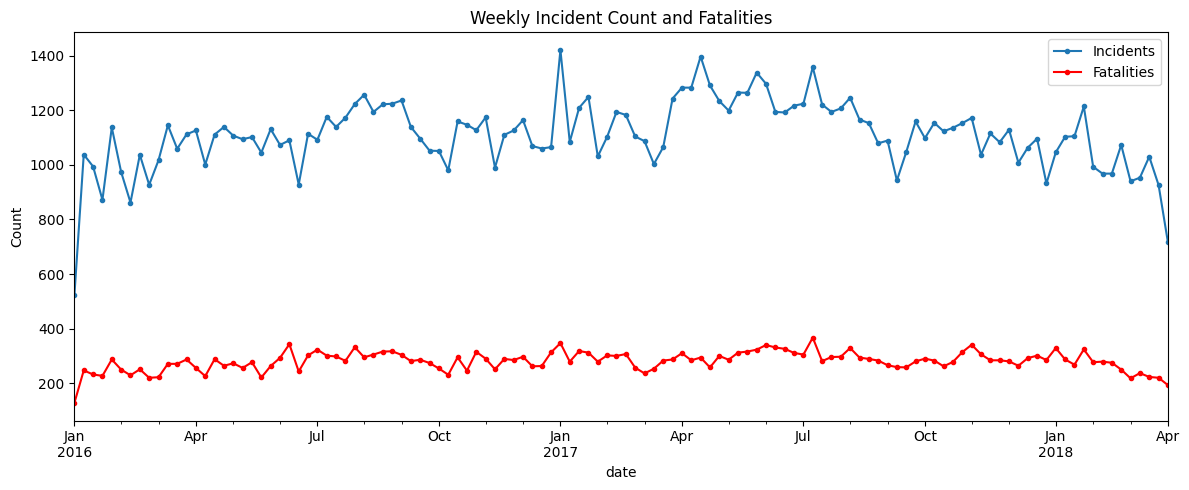

In [15]:
# Weekly aggregation - (W = weekly ending on Sunday)
weekly_stats = incidents_ts_df.resample('W').agg({
    'incident_id': 'count',
    'n_killed': 'sum',
    'n_injured': 'sum'
}).rename(columns={'incident_id': 'n_incidents'})

# Plot both series on a single plot with a shared y-axis
fig, ax = plt.subplots(figsize=(12, 5))

weekly_stats['n_incidents'].plot(ax=ax, marker='o', markersize=3, label='Incidents')
weekly_stats['n_killed'].plot(ax=ax, marker='o', markersize=3, color='red', label='Fatalities')

ax.set_title('Weekly Incident Count and Fatalities')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


## Rolling Windows: Moving Calculations

Rolling windows let you calculate statistics over a sliding window of time. This is essential for smoothing noisy data and identifying trends.

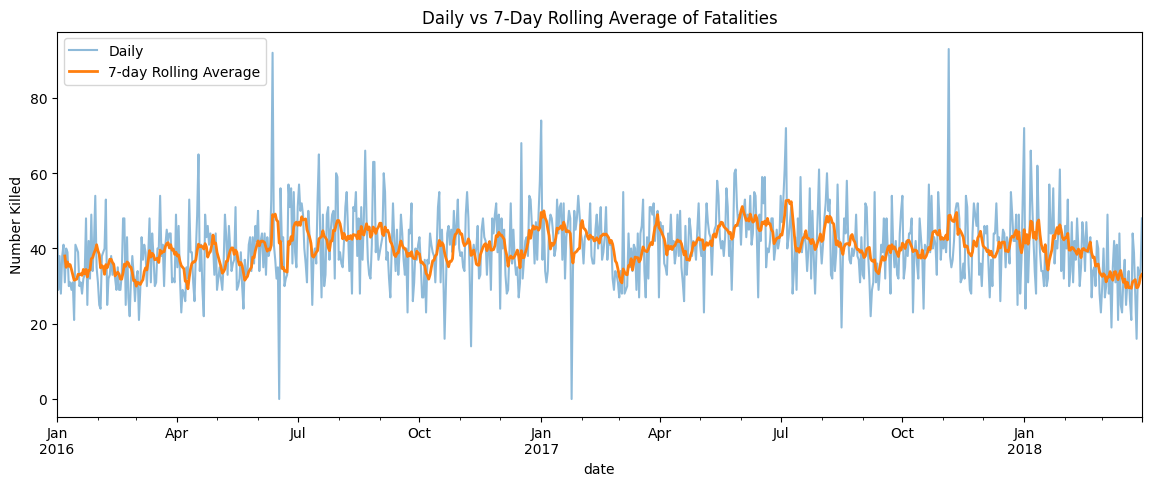

In [16]:
# Calculate 7-day rolling sum of killed
# First, create a daily series of killed counts
daily_killed = incidents_ts_df['n_killed'].resample('D').sum() # Daily 

# Now calculate 7-day rolling average
rolling_7day = daily_killed.rolling(window=7).mean()

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 5))
daily_killed.plot(ax=ax, alpha=0.5, label='Daily')
rolling_7day.plot(ax=ax, linewidth=2, label='7-day Rolling Average')
ax.set_title('Daily vs 7-Day Rolling Average of Fatalities')
ax.set_ylabel('Number Killed')
ax.legend()
plt.show()

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  <b>Rolling windows and missing data:</b> By default, rolling calculations return NaN if the window doesn't have enough data (e.g., the first 6 days for a 7-day window). Use <code>min_periods</code> parameter to require fewer observations.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Complex Time Pattern: "Last N Days" Calculations

A very common business question is: "For each row, what happened in the last N days?" For example, "What was the total killed in the 14 days before each incident?"

This is more complex because we need to look backwards from each individual row. For our data, there are many incidents on most days. Let's narrow it down to just incidents that occurred in LA.

In [17]:
# Filter to Los Angeles incidents only
LA_incidents_df = incidents_ts_df.loc[(incidents_ts_df['state'] == 'California') & (incidents_ts_df['city_or_county'] == 'Los Angeles'), :].copy()

# Calculate n_killed_last_14_days for each incident
# This means: sum of killed in the 14 days BEFORE this incident's date

# First, create a daily series of killed
LA_daily_killed = LA_incidents_df['n_killed'].resample('D').sum()

# Create a 14-day rolling sum
LA_rolling_killed = LA_daily_killed.rolling(window=14).sum()

# Shift by 1 to exclude the current day (we want BEFORE this date)
LA_killed_last_14_days_lookup = LA_rolling_killed.shift(1)

# Map back to original incidents using the index
LA_incidents_df['n_killed_last_14_days'] = LA_incidents_df.index.map(LA_killed_last_14_days_lookup)

print("Incidents with 'killed in last 14 days':")
print(LA_incidents_df[['incident_id', 'n_killed', 'n_killed_last_14_days']].tail(20))

Incidents with 'killed in last 14 days':
            incident_id  n_killed  n_killed_last_14_days
date                                                    
2018-02-06      1044214         0                    4.0
2018-02-07      1045662         0                    4.0
2018-02-12      1048884         1                    3.0
2018-02-14      1050304         0                    3.0
2018-02-25      1057942         1                    1.0
2018-02-26      1057944         1                    2.0
2018-03-01      1060286         0                    2.0
2018-03-03      1062160         0                    2.0
2018-03-05      1062701         1                    2.0
2018-03-07      1074215         0                    3.0
2018-03-07      1065774         0                    3.0
2018-03-12      1074222         1                    2.0
2018-03-12      1074212         0                    2.0
2018-03-16      1071679         1                    2.0
2018-03-16      1074147         0              

To show how much work this would be to do this by hand, let's pick a single day (randomly from the index of the dataframe) and manually calculate the number of incidents in the 14 days prior:

In [18]:
# Verify: Manually calculate killed in 14 days before a specific date
test_date = LA_incidents_df.index[50]  # Remember the date is the index of this dataframe; let's just pick the date of some particular row (50)
print(f"Testing date: {test_date}")

# Filter incidents in the 14 days before test_date (exclusive)
start_date = test_date - pd.Timedelta(days=14)
mask = (LA_incidents_df.index >= start_date) & (LA_incidents_df.index < test_date)
manual_count = LA_incidents_df.loc[mask, 'n_killed'].sum()

print(f"Manual calculation: {manual_count}")
print(f"Our calculation: {LA_incidents_df['n_killed_last_14_days'].iloc[50]}")

Testing date: 2016-04-01 00:00:00
Manual calculation: 5
Our calculation: 5.0


## Handling Missing Dates

Real-world time series data often has gaps - days with no records. This can cause problems with rolling calculations:

In [19]:
# Create a series with missing dates
sparse_data = pd.DataFrame({
    'date': pd.to_datetime(['2024-01-01', '2024-01-03', '2024-01-08', '2024-01-10']),
    'value': [10, 20, 15, 25]
}).set_index('date')

print(f"Sparse data (note missing dates)\n{'='*35}\n{sparse_data}\n")

# Rolling mean doesn't know about the gaps!
print(f"Rolling mean (3-day window) - gaps not handled\n{'='*45}")
print(sparse_data.rolling(window=3).mean())

Sparse data (note missing dates)
            value
date             
2024-01-01     10
2024-01-03     20
2024-01-08     15
2024-01-10     25

Rolling mean (3-day window) - gaps not handled
            value
date             
2024-01-01    NaN
2024-01-03    NaN
2024-01-08   15.0
2024-01-10   20.0


In the above, it's not the first two `NaN` entries that are problematic (our data has to start somewhere any "last N days" calculation will be undefined in the beginning). But look at `2014-01-08` which does have three days prior in the range of our collected data.  Presumably `value=0` for these days, but the rolling 3-day mean doesn't infer that automatically. If we want to **impute** missing data as zero, we have to `reindex` and explicitly fill missing values with some `fill_value`:

In [20]:
# Solution: Reindex to fill in missing dates, then calculate
full_date_range = pd.date_range(start=sparse_data.index.min(), end=sparse_data.index.max())
sparse_filled = sparse_data.reindex(full_date_range, fill_value=0)

print(f"Data with filled missing dates\n{'='*35}\n{sparse_filled}\n")

print(f"Rolling mean (3-day window) - gaps handled\n{'='*45}")
print(sparse_filled.rolling(window=3).mean())

Data with filled missing dates
            value
2024-01-01     10
2024-01-02      0
2024-01-03     20
2024-01-04      0
2024-01-05      0
2024-01-06      0
2024-01-07      0
2024-01-08     15
2024-01-09      0
2024-01-10     25

Rolling mean (3-day window) - gaps handled
                value
2024-01-01        NaN
2024-01-02        NaN
2024-01-03  10.000000
2024-01-04   6.666667
2024-01-05   6.666667
2024-01-06   0.000000
2024-01-07   0.000000
2024-01-08   5.000000
2024-01-09   5.000000
2024-01-10  13.333333


## Shifting and Lagging

The `shift()` method moves data forward or backward in time. This is useful for calculating period-over-period changes:

Month-over-month analysis (first 10 rows)
            current_month  previous_month  next_month  month_over_month_change  pct_change
date                                                                                      
2016-01-31           1121             NaN       976.0                      NaN         NaN
2016-02-29            976          1121.0      1168.0                   -145.0       -12.9
2016-03-31           1168           976.0      1135.0                    192.0        19.7
2016-04-30           1135          1168.0      1134.0                    -33.0        -2.8
2016-05-31           1134          1135.0      1258.0                     -1.0        -0.1
2016-06-30           1258          1134.0      1371.0                    124.0        10.9
2016-07-31           1371          1258.0      1354.0                    113.0         9.0
2016-08-31           1354          1371.0      1199.0                    -17.0        -1.2
2016-09-30           1199          1354.0      1

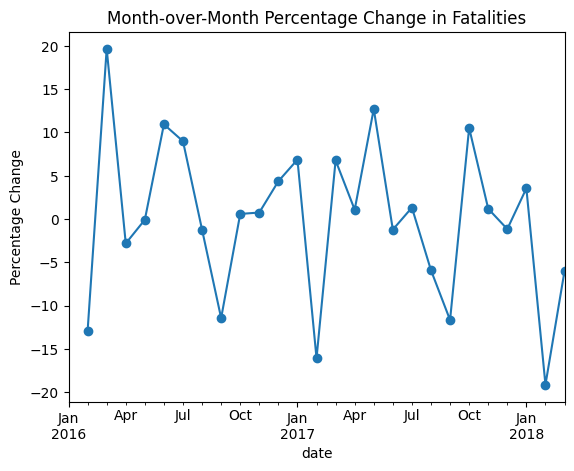

In [21]:
# Monthly data
monthly_stats = incidents_ts_df['n_killed'].resample('ME').sum() # 'ME' = month end

# Create a DataFrame to show different shifts
shift_demo = pd.DataFrame({
    'current_month': monthly_stats,
    'previous_month': monthly_stats.shift(1), # note: a positive shift moves the data down, so the previous month value will be aligned with the current month
    'next_month': monthly_stats.shift(-1),    #       similarly, a negative shift moves the data up, so the next month value will be aligned with the current month
    'month_over_month_change': monthly_stats - monthly_stats.shift(1),
    'pct_change': monthly_stats.pct_change() * 100, # here we're making use of the pct_change() method, though we could have done it manually.
})

print(f"Month-over-month analysis (first 10 rows)\n{'='*100}")
print(shift_demo.round(1).head(10))
shift_demo['pct_change'].plot(title='Month-over-Month Percentage Change in Fatalities', ylabel='Percentage Change', marker='o');

You might have noticed in the above example that when we called `shift()`, it converted the integer type to a float. This is because the shifted values introduce `NaN` for the first row, and `NaN` exists only for a `float` datatype (at least, with the default Pandas backend). 

<!-- Start Exercise 6.2 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise: Rolling Calculations </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
Using the provided DataFrame <code>idf</code> and focusing on <b>Chicago</b>:
<ol>
<li>Calculate the 30-day rolling average of incidents per day</li>
<li>Calculate the 7-day rolling sum of injured</li>
<li>Find which month had the highest week-over-week increase in incidents</li>
</ol>
Handle any missing dates appropriately!
</div>

In [25]:
# Exercise: Rolling calculations
import pandas as pd
idf = pd.read_feather('../data/gva.feather').set_index('date')

# 1. Create daily incident counts and calculate 30-day rolling average
CHI_incidents_df = incidents_ts_df.loc[(incidents_ts_df['state'] == 'Illinois') & (incidents_ts_df['city_or_county'] == 'Chicago'), :].copy()
CHI_daily_killed = CHI_incidents_df['n_killed'].resample('D').sum()
CHI_rolling_30day = CHI_daily_killed.rolling(window=30).mean()

# 2. Calculate 7-day rolling sum of injured
CHI_daily_injured = CHI_incidents_df['n_injured'].resample('D').sum()
CHI_rolling_7day = CHI_daily_injured.rolling(window=7).sum()

# 3. Find month with highest week-over-week increase
weekly_killed = CHI_incidents_df['n_killed'].resample('W').sum()
weekly_pct_change = weekly_killed.pct_change() * 100
max_increase_week = weekly_pct_change.idxmax()
max_increase_month = max_increase_week.to_period('M')
max_increase_value = weekly_pct_change.max()
print(f"Month with highest week-over-week increase: {max_increase_month}")
print(f"Increase value: {max_increase_value:.1f}%")

Month with highest week-over-week increase: 2017-03
Increase value: 900.0%


<hr/>
<!-- End Exercise 6.2 -->

# 6.3 Geospatial Data with GeoPandas

<img alt="Geospatial analysis is an important tool" src="../images/L06_indy_travel.png" width="900" style="display:block;">
<font size=2>Indiana Jones travels towards Nepal in <i>Raiders of the Lost Ark (1981)</i> </font>

Geospatial data adds another dimension to analysis. Instead of just asking "when did this happen?" we can also ask "where did this happen?" and visualize patterns on maps.

**GeoPandas** extends pandas to work with geographic data, enabling us to:
- Load and manipulate shapefiles, GeoJSON, and other spatial formats
- Perform spatial operations (joins, intersections, buffers)
- Create maps and visualizations

In [26]:
# Import geopandas (in case it isn't already)
import geopandas as gpd
from shapely.geometry import Point # Geopandas uses shapely for geometric objects

## Creating GeoDataFrames from Coordinates

If you have latitude and longitude data, you can convert a regular DataFrame to a GeoDataFrame:

In [27]:
# Make a GeoDataFrame from our original dataframe by adding the geometry column

# Define the geometry column
geometry = [Point(xy) for xy in zip(incidents_df['longitude'], incidents_df['latitude'])] # first we have to define the geometry column. Here it is based on Point() objects defined from the lon/lat pairs

# Make a geodataframe from our original dataframe by adding the geometry column
incidents_gdf = gpd.GeoDataFrame(incidents_df, geometry=geometry) # I like to use the suffix '_df' for dataframe and '_gdf' for "geo data frame"

# Set the coordinate reference system (CRS) -- EPSG:4326 is the standard lat/lon coordinates (WGS84)
incidents_gdf.set_crs(epsg=4326, inplace=True)

print(f"Type: {type(incidents_gdf)}")
print(f"CRS: {incidents_gdf.crs}")

print(incidents_gdf.head())

Type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:4326
   incident_id       date          state city_or_county                         address  n_killed  n_injured                                       incident_url  \
0       477000 2016-01-01  Massachusetts         Boston                Fairmount Street         0          1  http://www.gunviolencearchive.org/incident/477000   
1      1023080 2016-01-01    Connecticut        Meriden         Hobart St and Myrtle St         0          0  http://www.gunviolencearchive.org/incident/102...   
2       476977 2016-01-01       Missouri    Kansas City   12th Street and Denver Avenue         0          1  http://www.gunviolencearchive.org/incident/476977   
3       476979 2016-01-01       Missouri    Kansas City         39th Street and U.S. 71         0          1  http://www.gunviolencearchive.org/incident/476979   
4       476661 2016-01-01      Wisconsin         Cudahy  3700 block of E. Whittaker Ave         2          0  http://w

## Loading Geographic Boundaries

GeoPandas can load shapefiles, GeoJSON, and other spatial formats. Let's load US state boundaries:

In [28]:
# Load US states shapefile

# For this example, we'll use state boundaries from the US Census Bureau "Tiger Files" 
# More generally, gpd.read_file() can open both .shp and .geojson files (but note that opening a .shp requires all other associated files to be present)

us_states_gdf = gpd.read_file('../data/tl_2018_us_state_shapefile/tl_2018_us_state.shp') 
map = us_states_gdf.explore().save('../us_states_map.html')

Because vscode doesn't always play nice with interactive chloropleths, we'll save it to an `.html` file and instead open that file in a web browser. You can right click the file `us_states_map.html` in the explorer window of vscode and click "Copy Path" and then paste that into any web browser to see the map. Let's do it now.

## Simple Point Mapping

We could add all the data points to our existing interactive map, but instead, let's first explore creating a simple map using geopandas `.plot()` method, to show our Gun Violence incident locations:

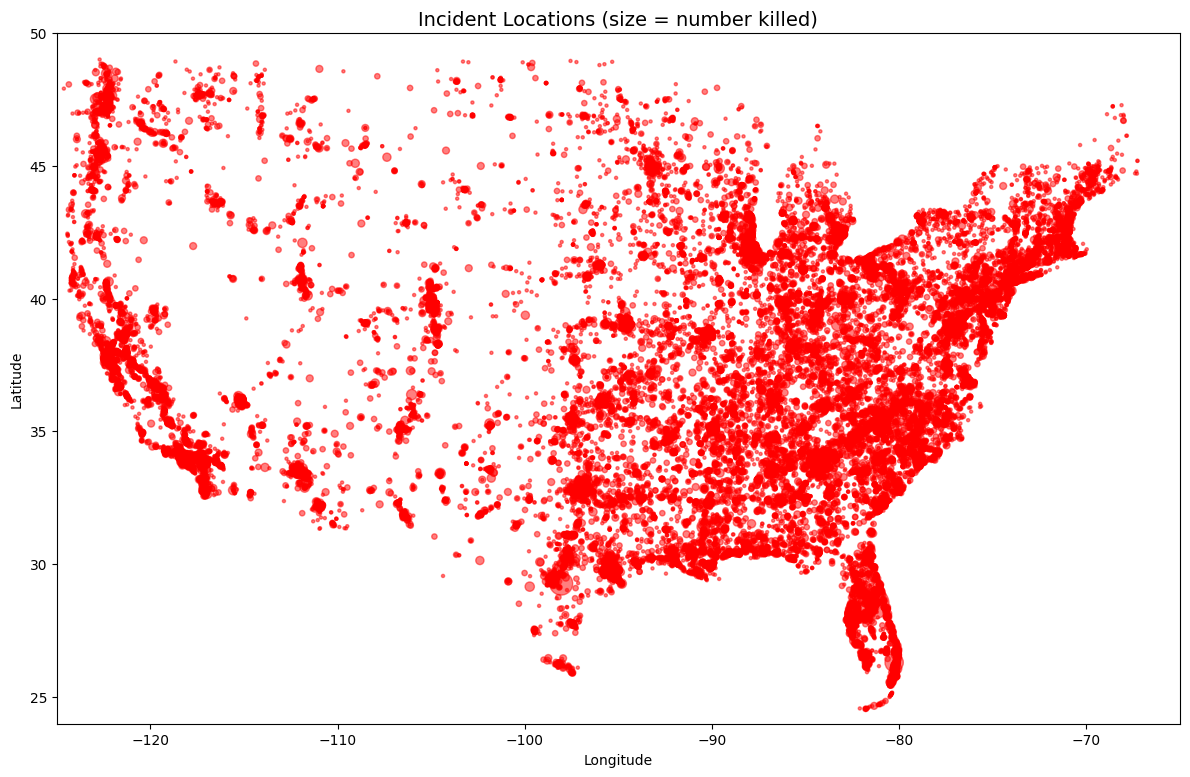

In [29]:
# Map Gun Violence Archive incidents as points in a simple scatter plot

# Create a simple scatter map of incidents
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all incidents
incidents_gdf.plot(
    ax=ax,
    markersize=incidents_gdf['n_killed'] * 10 + 5,  # Size based on n_killed
    alpha=0.5,
    color='red',
    legend=True
)

# Add title and labels
ax.set_title('Incident Locations (size = number killed)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set axis limits to continental US
ax.set_xlim(-125, -65)
ax.set_ylim(24, 50)

plt.tight_layout()
plt.show()

You can clearly see the outline of the United States from this data, even without a more sophisticated map that includes other context. Now let's plot our incident points in an interactive map. Because there are so many rows in the GVA data, it will take a few seconds to load it in our browser. If there are performance problems doing so, we can randomly sample from it instead:

In [30]:
# Create an interactive map with folium via geopandas .explore() for Gun Violence Archive incidents

# Un/comment below to plot 1000 randomly sampled incidents for a lighter map
incidents_sample = incidents_gdf.sample(n=1000, random_state=42)
incidents_sample.explore().save('../incidents_map.html')

# Un/comment below to plot all incidents for the full map
#incidents_gdf.explore().save('../incidents_map.html')

Open `incidents_map.html` in a web browser and play with it a bit.

## Coordinate Reference Systems (CRS)

One crucial concept in geospatial work is the **Coordinate Reference System (CRS)**. Different CRS are used for different purposes:

- **EPSG:4326 (WGS84)**: Standard lat/lon coordinates. Good for global data.
- **EPSG:3857 (Web Mercator)**: Used by Google Maps, OpenStreetMap. Good for web maps. Good when you want to do geometric operations in **meters**
- **State Plane or UTM**: Good for high-accuracy work in specific regions.

When combining data from different sources, you must ensure they use the same CRS!

In [31]:
# Check CRS of our data
print(f"Current CRS: {incidents_gdf.crs}")

Current CRS: EPSG:4326


In [32]:
# Transform to a different CRS (Web Mercator for example)
incidents_web_gdf = incidents_gdf.to_crs(epsg=3857)
print(f"Transformed CRS: {incidents_web_gdf.crs}")

Transformed CRS: EPSG:3857


Now let's look at both dataframes to see what changed in the `Geometry` column:

In [33]:
# Notice coordinates changed from degrees to meters
print(f"\nOriginal (incidents_gdf) (degrees)\n{"="*50}")
print(incidents_gdf[['longitude', 'latitude', 'geometry']].head(3))

print(f"\nTransformed (incidents_web_gdf) (meters)\n{"="*60}")
print(incidents_web_gdf[['longitude', 'latitude', 'geometry']].head(3))


Original (incidents_gdf) (degrees)
   longitude  latitude                  geometry
0   -71.0759   42.2802  POINT (-71.0759 42.2802)
1   -72.7895   41.5402  POINT (-72.7895 41.5402)
2   -94.5221   39.0979  POINT (-94.5221 39.0979)

Transformed (incidents_web_gdf) (meters)
   longitude  latitude                           geometry
0   -71.0759   42.2802   POINT (-7912132.996 5203044.896)
1   -72.7895   41.5402   POINT (-8102890.075 5092350.549)
2   -94.5221   39.0979  POINT (-10522152.041 4735704.625)


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    ⚠️
  </span>

  <b>CRS Gotcha</b>: If your points don't show up where expected on a map, or spatial joins produce unexpected results, the first thing to check is whether your data are in the same CRS! Use <code>.crs</code> to check and <code>.to_crs()</code> to transform.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Spatial Operations: Buffers and Joins

One of the killer features of GeoPandas is support for spatial operations like buffers (creating circles around points) and spatial joins (finding which polygon contains a point):

In [34]:
# Use the projected CRS to create a buffer (circle of radius 50km) around a particular point

# Create a buffer around each point (in the projected CRS)
# Note: buffer distance is in the units of the CRS (meters for EPSG:3857)
incidents_web_gdf['buffer'] = incidents_web_gdf.geometry.buffer(50000)  # 50km buffer

# Show one example
example_idx = 10
print(f"Original point: {incidents_gdf.geometry.iloc[example_idx]}")
print(f"Buffer (50km radius in Web Mercator): {incidents_web_gdf['buffer'].iloc[example_idx]}")

Original point: POINT (-84.1868 35.9142)
Buffer (50km radius in Web Mercator): POLYGON ((-9321631.707515165 4288821.83768874, -9321872.471181555 4283920.980672263, -9322592.443495004 4279067.321587934, -9323784.690728555 4274307.603826017, -9325437.730889602 4269687.6660704855, -9327535.644297747 4265252.00084744, -9330058.226900037 4261043.32603776, -9332981.184847029 4257102.173480558, -9336276.368455838 4253466.498629413, -9339912.043306982 4250171.315020603, -9343853.195864186 4247248.357073613, -9348061.870673865 4244725.774471323, -9352497.53589691 4242627.861063176, -9357117.473652443 4240974.82090213, -9361877.191414358 4239782.573668579, -9366730.850498687 4239062.601355131, -9371631.707515165 4238821.83768874, -9376532.564531643 4239062.601355131, -9381386.223615972 4239782.573668579, -9386145.941377888 4240974.82090213, -9390765.87913342 4242627.861063176, -9395201.544356465 4244725.774471323, -9399410.219166145 4247248.357073613, -9403351.371723348 4250171.315020603, -94069

You'll notice that above, I said a 50km circle around the `POINT`, but it is actually represented by shapely as a `POLYGON`.

Let's use this buffer idea to do something useful. Let's find all the incidents that occurred within 50km of the center of Chapman University. To do this we should go on Google Maps and find the lat/lon coordinates of Chapman University (I've done that already, but I'll show you now).

In [35]:
# Spatial join example: Find incidents within a certain distance of a city
# First, create a point for a location (e.g., Chapman University)
chapman = Point(-117.85184607722191, 33.79435739202488) # I found this point using Google Maps, but note that the order Google Maps gives is (lat, lon) while the order we want is (lon, lat)
chapman_gdf = gpd.GeoDataFrame(
    {'location_center': ['Chapman University']}, 
    geometry=[chapman], 
    crs='EPSG:4326'
)

After the above, the geomoetry of the dataframe is the single `Point` representing the location of Chapman University. We'll now make a buffer of 10km around that point, set that as the new geometry of the dataframe, and change the CRS to `EPSG:3857` so that the buffer is actually in meters instead of degrees:

In [36]:
# Create buffer around Chapman University (approximately 10km)
# For accurate distance, we should use a projected CRS
chapman_proj_gdf = chapman_gdf.to_crs(epsg=3857)
chapman_proj_gdf['buffer'] = chapman_proj_gdf.geometry.buffer(10000)  # 10km

# Set the buffer as the geometry
chapman_buffer_gdf = chapman_proj_gdf.set_geometry('buffer') # We made a new geodataframe, chapman_buffer_gdf, because each geodataframe can only have one "active" geometry column at a time.
# Transform incidents to same CRS
incidents_proj_gdf = incidents_gdf.to_crs(epsg=3857)

Now can use the `incidents_proj_gdf` (which has the gun violence incidents in the projected CRS) and the `chapman_buffer_gdf` (which has the 10km buffer around Chapman University in the same projected CRS) to do a spatial join and find all the incidents that occurred within 10km of Chapman University:

In [37]:
# Spatial join: find incidents within Chapman University buffer
incidents_near_chapman_gdf = gpd.sjoin(
    incidents_proj_gdf, 
    chapman_buffer_gdf, 
    how='inner', 
    predicate='within'  # Here the predicate is 'within' because we want points within the POLYGON of the other geometry (the buffer we made around Chapman)
)

print(f"Incidents within ~10km of Chapman University ({len(incidents_near_chapman_gdf)} total)\n{'='*180}")
print(incidents_near_chapman_gdf.head())
incidents_near_chapman_gdf.to_crs(epsg=4326).explore(color='red').save('../incidents_near_chapman_map.html')  # We can open this interactive map in a browser

Incidents within ~10km of Chapman University (123 total)
     incident_id       date       state city_or_county                             address  n_killed  n_injured                                       incident_url  \
171       477314 2016-01-01  California      Santa Ana    1700 block of South Cedar Street         0          1  http://www.gunviolencearchive.org/incident/477314   
187       477305 2016-01-01  California        Anaheim      300 block of South Bush Street         1          0  http://www.gunviolencearchive.org/incident/477305   
678       479720 2016-01-05  California      Santa Ana    1900 block of West Myrtle Street         0          1  http://www.gunviolencearchive.org/incident/479720   
679       479718 2016-01-05  California      Santa Ana  2600 block of West McFadden Avenue         0          1  http://www.gunviolencearchive.org/incident/479718   
866       479700 2016-01-06  California      Santa Ana  3400 block of West Chestnut Avenue         0          1  

You'll notice above that our `incidents_near_chapman_gdf` has two geometry columns (see if you can figure out where the `geometry_right` column came from).

Geopandas only allows one ***active geometry column*** at a time. If we need to switch it, we can set it with `gpd.GeoDataFrame(gdf, geometry="colname")`. If we don't, geopandas will asssume its the one named `geometry`.  

Let's open `incidents_near_chapman_map.html` and have a look.

## Creating a Choropleth with State Boundaries

A **choropleth map** colors regions based on the value of some metric of interest.

While we could aggregate by state using the `state` column of `incidents_gdf`, there are many cases where we won't have the regions of interest already defined for each row, but instead will just have lat/lon positions.

But we can make a chloropleth by using Geopandas to determine which incidents are inside the polygon of which State shapes, using a special kind of geo-merge. 

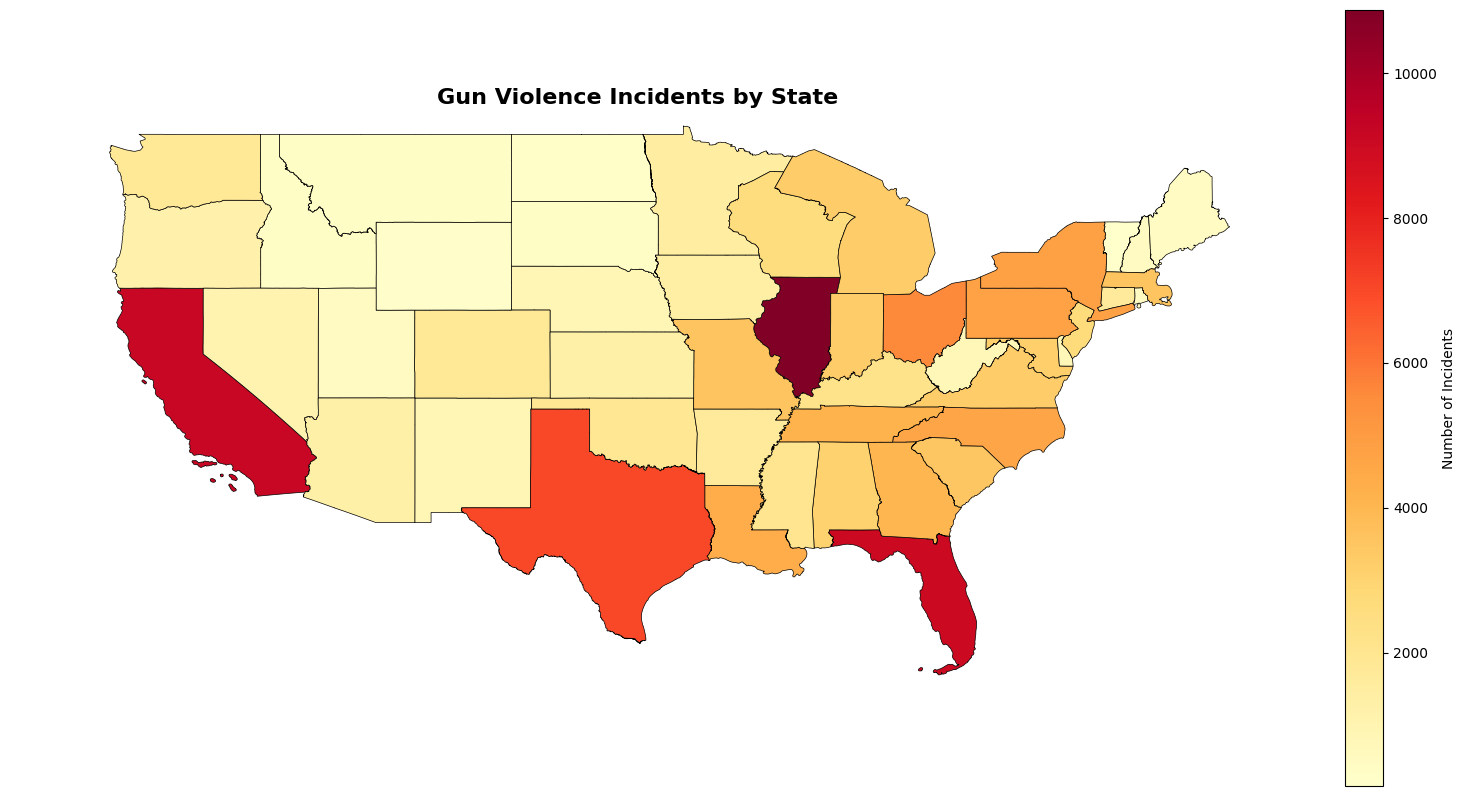

In [38]:
# Spatial join: match incidents to state polygons
incidents_by_state_gdf = gpd.sjoin(
    incidents_gdf,
    us_states_gdf.loc[:,['STUSPS', 'NAME', 'geometry']],
    how='left',
    predicate='within'
)

# Aggregate incidents by state
incidents_by_state_df = incidents_by_state_gdf.groupby('STUSPS').agg({
    'incident_id': 'count',
    'n_killed': 'sum',
    'n_injured': 'sum'
}).rename(columns={'incident_id': 'n_incidents'}).reset_index()

# Merge back to state boundaries for choropleth
us_states_choropleth = us_states_gdf.merge(
    incidents_by_state_df,
    left_on='STUSPS',
    right_on='STUSPS',
    how='left'
)

# Create choropleth map
fig, ax = plt.subplots(figsize=(16, 10))

us_states_choropleth.plot(
    column='n_incidents',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Number of Incidents', 'shrink': 0.8},
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'facecolor': 'lightgrey'}
)

ax.set_title('Gun Violence Incidents by State', fontsize=16, fontweight='bold')
ax.set_xlim(-130, -65) # Zoom to continental US  (otherwise viz too zoomed-out)
ax.set_ylim(24, 50) # Zoom to continental US
ax.set_axis_off()
plt.tight_layout()
plt.show()

<!-- Start Exercise 6.3 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise: Geospatial Analysis </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
Using the provided <code>idf</code> DataFrame and <code>igdf</code> GeoDataFrame:
<ol>
<li>Calculate the centroid (geographic center) of all incidents for each state</li>
<li>Create a visualization showing incident density (per square km) by state</li>
<li>Find all incidents within 50km of <b>Punxsutawney, PA</b> (lat: 40.945, lon: -78.9562)</li>
</ol>
</div>

In [ ]:
# Exercise: Geospatial analysis
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
idf = pd.read_feather('../data/gva.feather')
geometry = [Point(xy) for xy in zip(idf['longitude'], idf['latitude'])]
igdf = gpd.GeoDataFrame(idf, geometry=geometry)
igdf.set_crs(epsg=4326, inplace=True)


# 1. Calculate centroid for each state
# Hint: Use dissolve() and .centroid
state_centroids = igdf.dissolve(by='state').centroid

# 2. Create visualization of incident density (incidents per square km)
us_states_gdf = gpd.read_file('../data/tl_2018_us_state_shapefile/tl_2018_us_state.shp')
us_states_gdf = us_states_gdf.to_crs(epsg=3857)  # Project to Mercator for area calculation
us_states_gdf['area_km2'] = us_states_gdf.geometry.area / 1e6  # Convert from m^2 to km^2
incidents_by_state = igdf.groupby('state').size().reset_index(name='n_incidents')
us_states_incidents_gdf = us_states_gdf.merge(
    incidents_by_state,
    left_on='NAME',
    right_on='state',
    how='left'
)

# drop DC since it's such a crazy outlier and the plot had no distinction otherwise
us_states_incidents_gdf = us_states_incidents_gdf[us_states_incidents_gdf['NAME'] != 'District of Columbia']

us_states_incidents_gdf['incident_density'] = us_states_incidents_gdf['n_incidents'] / us_states_incidents_gdf['area_km2']
us_states_incidents_gdf = us_states_incidents_gdf.to_crs(epsg=4326) # Return to lat/lon projection for plot

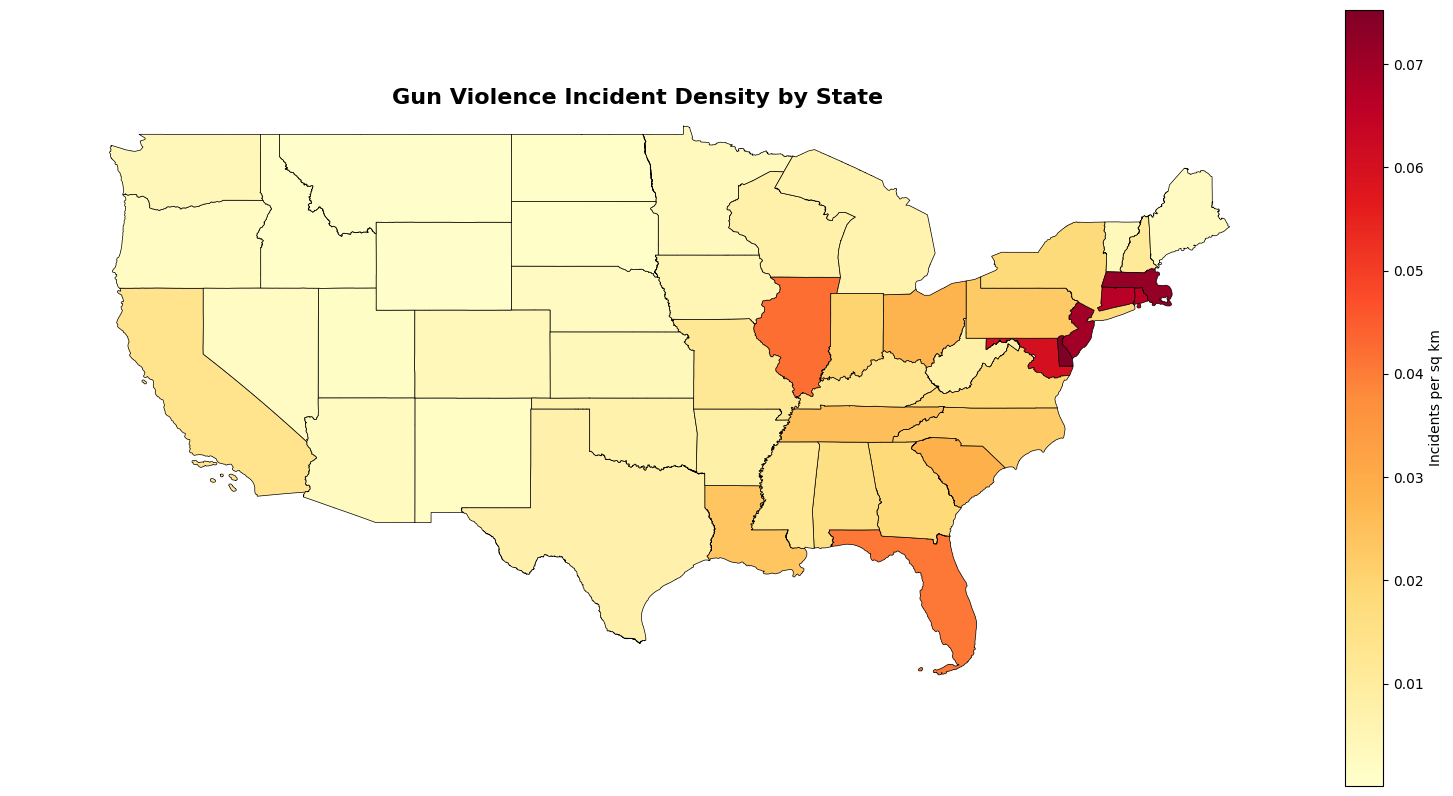

In [ ]:
# Plot choropleth of incident density
fig, ax = plt.subplots(figsize=(16, 10))
us_states_incidents_gdf.plot(
    column='incident_density',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Incidents per sq km', 'shrink': 0.8},
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'facecolor': 'lightgrey'}
)
ax.set_title('Gun Violence Incident Density by State', fontsize=16, fontweight='bold')
ax.set_xlim(-130, -65) # Zoom to continental US
ax.set_ylim(24, 50) # Zoom to continental US
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [62]:
# 3. Find incidents within 50km of Punxsutawney, PA
# Hint: Create a point for Punxsutawney,PA, buffer it, do a spatial join
punxsutawney_point = Point(-79.845, 41.442)

punxsutawney_gdf = gpd.GeoDataFrame(
    {'location_center': ['Punxsutawney, PA']}, 
    geometry=[punxsutawney_point], 
    crs='EPSG:4326'
)

punxsutawney_proj_gdf = punxsutawney_gdf.to_crs(epsg=3857)
punxsutawney_proj_gdf['buffer'] = punxsutawney_proj_gdf.geometry.buffer(50000)  # 50km

incidents_proj_gdf = incidents_gdf.to_crs(epsg=3857)

punxsutawney_buffer_gdf = punxsutawney_proj_gdf.set_geometry('buffer')

incidents_near_punxsutawney = gpd.sjoin(
    incidents_proj_gdf, 
    punxsutawney_buffer_gdf, 
    how='inner', 
    predicate='within'
)

print(f"Incidents within 50km of Punxsutawney, PA: {len(incidents_near_punxsutawney)}\n")
print(incidents_near_punxsutawney.head())

Incidents within 50km of Punxsutawney, PA: 15

       incident_id       date         state city_or_county                 address  n_killed  n_injured                                       incident_url  \
22436      1003631 2016-05-29  Pennsylvania       Tionesta              217 Elm St         0          0  http://www.gunviolencearchive.org/incident/100...   
35867       638248 2016-08-20  Pennsylvania       Franklin        1285 Mercer Road         2          0  http://www.gunviolencearchive.org/incident/638248   
36485       638236 2016-08-23  Pennsylvania      Meadville                     NaN         0          1  http://www.gunviolencearchive.org/incident/638236   
51828       713863 2016-11-27  Pennsylvania       Franklin          900 Pioneer Rd         0          1  http://www.gunviolencearchive.org/incident/713863   
54889       728234 2016-12-17  Pennsylvania      Meadville  1237 South Main Street         0          2  http://www.gunviolencearchive.org/incident/728234   

    

<hr/>
<!-- End Exercise 6.3 -->

# Summary

In this lecture, we covered three essential areas for data analysis:

## Validating Merges and Joins
- **The `indicator` parameter**: Track where each row came from
- **The `validate` parameter**: Enforce expected relationships (1:1, m:1, 1:m)
- **Always verify**: Check row counts, look for missing keys, validate relationships
- Pandas won't warn you about silent data corruption - you must actively check!

## Advanced Time Aggregation
- **DateTime indexing**: Set dates as index for time-based operations
- **Resampling**: Aggregate data to different time frequencies (daily, weekly, monthly)
- **Rolling windows**: Calculate moving statistics (7-day average, etc.)
- **"Last N days" patterns**: Calculate lookback windows for each row
- **Handling missing dates**: Use `reindex()` to fill gaps before calculations
- **Shifting and lagging**: Calculate period-over-period changes

## Geospatial Data with GeoPandas
- **GeoDataFrames**: Extend pandas with spatial capabilities
- **Creating from coordinates**: Convert lat/lon to geometry points
- **Coordinate Reference Systems (CRS)**: Always check and align CRS across datasets
- **Spatial operations**: Buffers, spatial joins, point-in-polygon
- **Choropleth maps**: Color regions based on aggregated values

These skills are essential for analyzing real-world data that has both temporal and spatial dimensions.

## Key Takeaways
<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
  display: flex;
  align-items: flex-start;
">
  <div style="
    font-size: 60pt;
    line-height: 1;
    width: 48px;
    display: flex;
    align-items: flex-start;
  ">
    🎯
  </div>
<div style="padding: 0px; margin:0 0 0 60px;">

- **Always validate merge operations** - pandas won't always warn you about problems
- **Time series data requires special handling** - missing dates can corrupt rolling calculations
- **Window functions are powerful but expensive** - think about efficiency for large datasets
- **CRS matters** - mismatched coordinate systems are a common source of bugs in geospatial work
- **Geospatial analysis opens new possibilities** - location adds a rich dimension to your analysis

</div>
</div>

# Your Turn: Questions, Reactions, and Feedback

As always, I'd like to hear your thoughts on this material:

1. What concepts were most new or surprising to you?

2. What would you like to see explained in more depth?

3. Any questions that came up as you worked through the notebook?

4. Have you worked with time series or geospatial data before? How do these techniques compare to what you've done?

**Write your thoughts below:**

*[Your reflections here]*